# **10주차 과제**

<b>안내사항</b>
- 셀 출력 결과물은 이미지로 첨부하였습니다.
- Colab에서 확인할 시에 출력 이미지가 안보일 수 있습니다.
- VS Code 등의 로컬 환경을 이용하시거나 참고 이미지 폴더의 이미지 파일들을 참고하시길 바랍니다.
- 데이터 정렬에서 인덱스 번호는 따로 신경쓰지 않으셔도 괜찮습니다.  
  ※ 이름, 수치 등의 명시된 조건에 대해서만 신경써주시길 바랍니다.

# Q1~Q2 클래스 설계 문제

- **Q1 생성자 메서드 설정**
    - **생성자 메서드는 아래와 같이 구성되어야 합니다.**  
        - 속성 할당 및 데이터프레임 정보 출력을 수행합니다.  
    - 객체 생성과 속성 설정 과정이 올바르게 수행되는지 평가합니다.

- **Q2 메서드 구현 - 데이터 전처리/변형**
    - **데이터 전처리/변형 메서드는 아래와 같이 구성되어야 합니다.**  
        - 데이터프레임을 Long Form 형태로 변환합니다.  
    - 메서드 이름은 자유이며, 코드셀에 나타난 메서드 이름은 참고로만 활용하셔도 됩니다.  

**확인사항**  
- 클래스 이름, 메서드 이름은 자유롭게 설정하셔도 되며 동일한 결과를 나타내시면 됩니다.   
- 입력인자는 꼼꼼하게 확인해주시길 바랍니다.  
- print, display 함수도 꼼꼼하게 확인하여 출력 결과를 만들어주시길 바랍니다.

In [ ]:
# 불필요한 출력을 없애기 위한 코드입니다.
# 문제풀이와는 무관합니다.
import warnings
warnings.filterwarnings('ignore')

In [ ]:

import pandas as pd
class prep_class:
    def __init__(self, df, id_col):
        # 1. 속성 할당
        self.df = df
        self.id_col = id_col
        self.melt_df = None 

        # 2. 초기 정보 출력 (이미지 4번 형식)
        print("==================== 데이터프레임 중 일부 데이터를 출력합니다. ====================")
        print(self.df.shape)
        display(self.df.head(5))

        print("\n==================== 데이터프레임 info를 출력합니다. ====================")
        self.df.info()

        print("\n==================== 데이터프레임 describe를 출력합니다. ====================")
        display(self.df.describe())

    def transform_melt(self, var_name, value_name, value_col_list):
        # 1. 변환 전 출력 (이미지 5번 상단)
        print("==================== 변환 이전의 데이터프레임 형태입니다. ====================")
        print(self.df.shape)
        display(self.df.head(5))

        # 2. 데이터 변환 (Melt)
        melted = self.df.melt(id_vars=self.id_col, 
                              value_vars=value_col_list, 
                              var_name=var_name, 
                              value_name=value_name)

        # 3. 중요!! 이름순 정렬 (이미지 5번의 'Abomasnow' 결과를 만들기 위한 핵심)
        # 정렬을 해야 이름이 'A'로 시작하는 포켓몬들이 위로 올라옵니다.
        self.melt_df = melted.sort_values(self.id_col)

        # 4. 변환 후 출력 (이미지 5번 하단 - '이후후' 오타 반영)
        print("\n==================== 변환 이후후의 데이터프레임 형태입니다. ====================")
        print(self.melt_df.shape)
        display(self.melt_df.head(5))

## Q1. 클래스 선언 / 생성자 메서드 설정

- 데이터 읽기 및 정보확인용 코드셀입니다.

In [ ]:
import pandas as pd

tmp_df = pd.read_csv('./data_과제/pokemon_prep.csv')
display(tmp_df.head())

display(tmp_df['Name'].value_counts().sort_values(ascending=False).head()) # 겹치는 데이터가 있는지 확인하는 과정입니다.
display(tmp_df['Name'].value_counts().sort_values(ascending=True).head()) # 겹치는 데이터가 있는지 확인하는 과정2입니다.

# <img src="./참고이미지/Q1/Q1_0.png" width="100%">

<b>객체 생성 코드 셀</b>
- 이 셀에서는 객체 생성 코드만 작성합니다.
- 데이터프레임 정보 출력은 객채 생성시에 자동으로 출력되도록 구현하세요.

<b>참고</b>
- 클래스의 생성자 메서드가 어떻게 동작하는지 고민해보세요.
- 아래 지정된 외에 다른 코드를 추가하여 해당 결과를 구현할 경우, 오답으로 처리될 수 있습니다.

In [ ]:


tmp_class = prep_class(df=tmp_df,
                       id_col='Name')



<img src="./참고이미지/Q1/Q1_1.png" width="100%">

<b>코드 Cell</b>
- [Q1] 객체의 속성을 확인합니다.
- 속성이 제대로 설정되었는지 확인하기 위한 코드셀입니다.
- 동일한 결과가 나타나는지 확인해주시면 됩니다.

In [ ]:
display(tmp_class.df)

print(tmp_class.id_col)

<img src="./참고이미지/Q1/Q1_2.png" width="100%">

## Q2. 데이터 변형 메서드 구현

<b>설명</b>
- [Q1~Q2 클래스 설계 문제] - Q2 메서드를 실행합니다.

- 정렬 순서도 지켜주셔야 하며, 정렬 과정은 메서드 내에서 구현되어야 합니다.
- 정렬은 Name 컬럼 기준으로 오름차순으로 정렬합니다.

In [ ]:
# 반드시, 해당 셀에는 메서드 실행과 속성 출력 이외에는 어떠한 코드도 작성되지 않아야 합니다.
# 메서드 실행, 속성 출력 두 가지 코드만 입력 부탁드립니다.
# 셀 출력 결과를 얻기 위해, 별도의 초드를 추가하는 경우 오답으로 처리될 수 있습니다.

tmp_class.transform_melt(var_name = 'ability',
                         value_name = 'score',
                         value_col_list=['HP', 'Attack', 'Defense',
                                       'Special Attack', 'Special Defense', 'Speed'])




<img src="./참고이미지/Q2/Q2_1.png" width="100%">

<b>코드 Cell</b>
- 속성 확인 결과입니다.
- 동일한 결과를 출력할 수 있어야 합니다.

In [ ]:
tmp_class.melt_df

<img src="./참고이미지/Q2/Q2_2.png" width="100%">

# Q3. 함수 선언 - 요구된 명령어에 맞게 동작하는 함수를 설계해주세요

<b>1. 문제설명) 명령어에 맞게 동작을 수행하는 사용자 정의 함수를 선언해주세요</b>
- Boxplot 시각화 : 입력된 컬럼들에 대하여 boxplot 시각화를 수행합니다.
- 상관관계 시각화 : 입력된 컬럼들에 대하여 상관관계 시각화를 수행합니다.
- 정지 : "동작을 정지합니다."를 출력한 이후 동작을 종료합니다.
- 위에 해당하지 않는 경우 : "존재하지 않는 명령어입니다. 다시 실행합니다."를 출력 후, 다시 명령어 입력 동작을 수행합니다.

<b>2. 명령어 입력</b>
- 명령어 입력은 input 함수를 통해 이루어졌습니다.

<b>3. 셀 출력 순서</b>
- 아래의 사용자 정의 함수 출력은 아래 명령어 순서에 따라 이루어졌습니다.  
    - "Boxplot 시각화" 입력  
    - "상관관계 시각화" 입력  
    - "존재하지 않는 명령어(=어떤 문장이든 상관없습니다.)" 입력  
    - "정지" 입력 후, 동작 정지  

<b>4. 조건</b>
- "정지" 명령어를 입력하기 전에는 함수 동작이 종료되지 않아야 합니다.

<b>코드 Cell</b>
- 데이터를 새롭게 불러오기 위한 코드셀입니다.

In [ ]:
import pandas as pd

tmp_df = pd.read_csv('./data_과제/pokemon_prep.csv')
display(tmp_df.head())

display(tmp_df['Name'].value_counts().sort_values(ascending=False).head()) # 겹치는 데이터가 있는지 확인하는 과정입니다.
display(tmp_df['Name'].value_counts().sort_values(ascending=True).head()) # 겹치는 데이터가 있는지 확인하는 과정2입니다.

display(tmp_df.info())

<img src="./참고이미지/Q3/Q3_1.png" width="60%">

<코드 Cell>
- 함수 정의를 수행하는 코드셀입니다.
- 조건에 맞게 코드를 작성해주세요.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display # 데이터프레임을 표 형태로 깔끔하게 출력하기 위한 함수

def visualize_func(df, numeric_col_list):
    # 1. 무한 루프 진입 전: 함수 기본 실행 상태 1회 출력
    print("====================================== 경우의 수 : 함수 기본 실행 상태 ======================================")
    print("데이터프레임 데이터입니다.")
    display(df) # Jupyter Notebook 환경에서 표를 깔끔하게 렌더링
    
    print("\n컬럼 목록입니다.")
    print(numeric_col_list)
    print("명령어를 입력해주세요. 명령어 [Boxplot 시각화, 상관관계 시각화, 정지] ")
    
    # 2. 명령어 입력 무한 루프 시작
    while True:
        command = input("명령어를 입력해주세요. 명령어 [Boxplot 시각화, 상관관계 시각화, 정지] ")
        
        # [Case 1] Boxplot 시각화
        if command == "Boxplot 시각화":
            print("====================================== 경우의 수 : Boxplot 시각화 입력 ======================================")
            print("동작을 계속 수행합니다.")
            
            for col in numeric_col_list:
                plt.figure(figsize=(8, 4))
                sns.boxplot(x=df[col])
                plt.title(col)
                plt.show()
                
            print("Boxplot 시각화를 완료했습니다.")
            
        # [Case 2] 상관관계 시각화
        elif command == "상관관계 시각화":
            print("====================================== 경우의 수 : 상관관계 시각화 입력 ======================================")
            
            plt.figure(figsize=(8, 6))
            corr_matrix = df[numeric_col_list].corr()
            
            sns.heatmap(corr_matrix, annot=True)
            plt.title("Correlation Heatmap")
            plt.show()
            
            print("상관관계 시각화를 완료했습니다.")
            
        # [Case 3] 정지
        elif command == "정지":
            print("====================================== 경우의 수 : 정지 입력 ======================================")
            print("동작을 정지합니다.")
            break
            
        # [Case 4] 예외 처리 (그 외 명령어)
        else:
            print("====================================== 경우의 수 : 존재하지 않는 명령어 입력 ======================================")
            print("존재하지 않는 명령어입니다. 다시 실행합니다.")


<b>코드 실행 Cell</b>
1. 코드 Cell
    - 함수를 실행하는 코드셀입니다.

2. 조건
    - 반드시, 해당 코드셀에서는 함수 실행만 이루어져야 합니다.
    - 아래와 동일한 입력인자에 대해서, 동일한 출력이 이루어져야 합니다.
    - 출력 결과를 만족시키기 위해 추가 코드를 작성할 경우 오답으로 처리될 수 있습니다.
    - 명령어 입력은 input 함수를 통해 수행합니다.

In [ ]:
visualize_func(df=tmp_df,
               numeric_col_list = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed'])

<img src="./참고이미지/Q3/Q3_2.png" width="50%">

<img src="./참고이미지/Q3/Q3_3.png" width="55%">

<img src="./참고이미지/Q3/Q3_4.png" width="55%">

<img src="./참고이미지/Q3/Q3_5.png" width="55%">

# Q4. 데이터 전처리 - Pandas 데이터 전처리

<img src="./참고이미지/ERD_이미지.png" width="50%">

URL : https://www.mysqltutorial.org/getting-started-with-mysql/mysql-sample-database/

<b>1. 데이터</b>
- employees.csv
- customers.csv

<b>2. 설명</b>
- employees 데이터에는 reportsTo 컬럼이 존재합니다.
- reportTo에 적혀있는 employeeNumber를 가진 직원을 직속 상사, report를 하는 직원을 직속 부하로 취급합니다.
- 한 명의 상사가 여러 명의 부하가 있는 경우가 존재할 수 있습니다.
- 가장 상급자의 경우, 직속 상사가 없습니다.
- 자세한 세부 과정은 내용은 아래 전처리 과정들과 출력 결과를 참고 바랍니다.

<b>3. 최종 결과</b>    
- 최종적으로는, 직원별로 직속 부하들이 관리하는 고객들의 평균 creditLimit을 구합니다.

<b>코드 Cell</b>
- 데이터 확인 및 읽기용 코드셀입니다.
- 데이터 읽기에 활용하시거나, 참고용으로만 활용하시면 됩니다.

In [ ]:
import pandas as pd
employees_df = pd.read_csv('./data_과제/sampledatabase/employees.csv')
customeres_df = pd.read_csv('./data_과제/sampledatabase/customers.csv')

print('='*10, 'employees.csv 정보입니다.', '='*10)
display(employees_df.shape)
display(employees_df.head())

print('='*10, 'customers.csv 정보입니다.', '='*10)
display(customeres_df.shape)
display(customeres_df.head())

<img src="./참고이미지/Q4/Q4_1.png" width="70%">

<b>코드 Cell</b>
- employees 데이터에 대한 전처리 과정입니다.
- 직속 상사의 LastName, 직속 상사의 직급, 직속 부하의 LastName, 직속 부하의 직급, 직속부하의 직원번호 데이터를 정리합니다.
- 데이터를 적절히 분할하고 결합하는 과정이 필요할 수 있습니다.
- 셀 출력에서는 데이터를 간편하게 보기 위해, 컬럼 이름 변경, 컬럼 순서 변경 등의 작업을 수행했습니다.

In [ ]:
import pandas as pd

# 1. 중간 과정: 모든 직원(23명)의 상사 정보 붙이기 (23행 7열)
# President는 상사가 없으므로 left join을 사용해 NaN으로 표시합니다.
step1 = pd.merge(
    employees_df,
    employees_df[['employeeNumber', 'lastName', 'jobTitle']],
    left_on='reportsTo',
    right_on='employeeNumber',
    how='left',
    suffixes=('', '_Boss')
)

# 컬럼 이름 변경 (그림과 정확히 일치하게: BossLastName은 언더바 없음)
step1 = step1.rename(columns={
    'lastName': 'Reporter_LastName',
    'jobTitle': 'Reporter_JobTitle',
    'employeeNumber': 'Reporter_EmpNumber',
    'employeeNumber_Boss': 'Boss_EmpNumber',
    'lastName_Boss': 'BossLastName',
    'jobTitle_Boss': 'Boss_JobTitle'
})

# 그림에 나온 7개 컬럼 순서대로 정렬
step1_result = step1[['Reporter_LastName', 'Reporter_JobTitle', 'Reporter_EmpNumber', 'reportsTo', 'Boss_EmpNumber', 'BossLastName', 'Boss_JobTitle']]

print("-------------------------- 컬럼을 정리하는 중간 과정입니다. --------------------------")
print(step1_result.shape) # (23, 7) 출력 확인
display(step1_result.head())


# 2. 정리 결과: 상사가 있는 직원만 남기기 (22행 5열)
# reportsTo가 NaN인 President(Murphy)를 제외합니다.
step2_result = step1_result.dropna(subset=['reportsTo']).copy()

# 그림에 나온 5개 컬럼 순서대로 정렬
step2_cols = ['BossLastName', 'Boss_JobTitle', 'Reporter_LastName', 'Reporter_JobTitle', 'Reporter_EmpNumber']
step2_result = step2_result[step2_cols]

# 그림처럼 인덱스를 1부터 시작하게 변경
step2_result.index = range(1, len(step2_result) + 1)

print("========================== 직속 상사, 직속 부하에 대한 정리 결과입니다. ==========================")
print(step2_result.shape) # (22, 5) 출력 확인
display(step2_result.head())




<img src="./참고이미지/Q4/Q4_2.png" width="45%">

<b>코드 Cell</b>
- 위에서 정리한 데이터 정보와 customer.csv 정보를 결합합니다.
- salesRepEmployeeNumber에 적혀있는 직원번호가 해당 고객을 관리하는 직원의 직원번호입니다.

In [ ]:
import pandas as pd




# -------------------------- 전처리 데이터와 customeres_df 데이터를 병합합니다. --------------------------
# 3단계: 고객 데이터와 병합 (107행 18열)
# 이미지의 변수명 customeres_df를 그대로 사용합니다.
merge_all = pd.merge(
    step2_final,
    customeres_df,
    left_on='Reporter_EmpNumber',
    right_on='salesRepEmployeeNumber',
    how='left' # 고객이 없는 부하직원도 포함하기 위해 left merge
)

print("\n-------------------------- 전처리 데이터와 customeres_df 데이터를 병합합니다. --------------------------")
print(f"Index({list(merge_all.columns)}, dtype='object')")
print(f"({len(merge_all)}, {len(merge_all.columns)})")
display(merge_all.head(10))


# -------------------------- 필요한 컬럼 정보만 남겨 데이터를 정리합니다. --------------------------
# 4단계: 최종 집계 전 컬럼 정리 (107행 8열)
target_cols = ['BossLastName', 'Boss_JobTitle', 'Reporter_LastName', 'Reporter_JobTitle', 'Reporter_EmpNumber', 'salesRepEmployeeNumber', 'customerName', 'creditLimit']
step4_final = merge_all[target_cols]

print("\n-------------------------- 필요한 컬럼 정보만 남겨 데이터를 정리합니다. --------------------------")
print(f"({len(step4_final)}, {len(step4_final.columns)})")
display(step4_final.head(20)) # 여러 행을 보여주기 위해 20개 출력


<img src="./참고이미지/Q4/Q4_3.png" width="100%">

<b>코드 Cell</b>
- 최종 결과입니다.
- 직속 부하가 관리하는 고객들의 creditLimit의 평균값을 계산합니다.
- 집계한 creditLimit 정보를 기준으로 내림차순 정렬을 수행한 뒤에, 순위를 매깁니다.

In [ ]:

# [추가] 최종 랭킹 산출 (image_8ead6d 반영)
# 1. 고객이 없어 creditLimit이 NaN인 상사는 제외
# 2. 평균 creditLimit 기준 내림차순 정렬
final_rank = final_agg.dropna(subset=['creditLimit']).sort_values(by='creditLimit', ascending=False).reset_index(drop=True)

# 3. RANK 컬럼 추가 (1등부터 시작)
final_rank.insert(0, 'RANK', range(1, len(final_rank) + 1))

# 4. 이미지와 동일하게 컬럼명 대문자 처리 (선택 사항)
final_rank = final_rank.rename(columns={'Boss_JobTitle': 'BOSS_jobTitle'})

print("\n-------------------------- 최종 랭킹 결과 --------------------------")
display(final_rank)

<img src="./참고이미지/Q4/Q4_4.png" width="40%">

# Q5. 데이터 전처리 - Python MySQL

<b>주의사항</b>
- 반드시, 하나의 쿼리문을 통해 동일한 결과를 도출해야 합니다.
- 쿼리를 두 번에 나누어서 적용할 경우, 오답으로 처리될 수 있습니다.

In [ ]:
import mysql.connector
import pandas as pd

# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
        host='localhost',       # 보통 'localhost' 또는 '127.0.0.1'
        user='root',            # 사용자 이름 (예: 'root')
        password='kwj05',
        database='classicmodels'  # 사용하는 데이터베이스 이름
)

In [ ]:
# 반드시, 해당 셀에서는 하나의 쿼리문 입력과 pd.read_sql() 이외에는 어떠한 코드도 입력되어서는 안됩니다.
# 다른 코드를 추가하여 결과를 도출할 경우 오답으로 처리됩니다.

query = """
SELECT 
    RANK() OVER (ORDER BY AVG(c.creditLimit) DESC) AS `rank_val`,  -- 별명을 rank_val로 변경
    e2.lastName AS BossLastName,
    e2.jobTitle AS BOSS_jobTitle,
    AVG(c.creditLimit) AS avg_creditLimit                     -- 별명을 중복되지 않게 변경
FROM employees AS e1
JOIN employees AS e2 ON e1.reportsTo = e2.employeeNumber
JOIN customers AS c ON e1.employeeNumber = c.salesRepEmployeeNumber
GROUP BY e2.employeeNumber, e2.lastName, e2.jobTitle
ORDER BY avg_creditLimit DESC;                                 -- 위에서 정한 별명으로 정렬
"""

pd.read_sql(query, conn)

<img src="./참고이미지/Q5/Q5_1.png" width="80%">

# Q6. 데이터 전처리2 - Pandas 데이터 전처리

<b>1. 데이터</b>
- orders.csv / orderdetails.csv / customers.csv

<b>2. 최종 결과</b>
- 고객별로 가장 큰 주문금액, 가장 작은 주문 금액, 이들의 차이에 대한 데이터를 구합니다.  
- 이들을 각격 차이를 기준으로 내림차순하고 20위까지 등수를 매깁니다.  
- 데이터 중에서 customer의 country는 USA, orders의 stauts는 Shipped로 필터링을 합니다.  

<b>※ 참고</b>
- 자세한 세부 과정은 내용은 아래 전처리 과정들과 출력 결과를 참고 바랍니다.

<b>코드 Cell 설명</b>
- 데이터 확인 및 읽기용 코드셀입니다.
- 데이터 읽기에 활용하시거나, 참고용으로만 활용하시면 됩니다.

In [ ]:
import pandas as pd
customers_df = pd.read_csv('./data_과제/sampledatabase/customers.csv')
orders_df = pd.read_csv('./data_과제/sampledatabase/orders.csv')
order_details_df = pd.read_csv('./data_과제/sampledatabase/orderdetails.csv')

print('========== customers_df 정보 ==========')
print(customers_df.shape)
display(customers_df.head())

print('========== orders_df 정보 ==========')
print(orders_df.shape)
display(orders_df.sort_values(by='customerNumber', ascending=True).head())

print('========== order_details_df 정보 ==========')
print(order_details_df.shape)
display(order_details_df.head())

<img src="./참고이미지/Q6/Q6_1.png" width="80%">

<b>코드 Cell 설명</b>
- orderdetails 데이터에서 total_order_value 컬럼을 추가 및 집계를 수행합니다.
    - total_order_value = quantityOrdered * priceEach로 계산합니다.
    - total_order_values는 총 주문금액을 의미합니다.
    - 집계 연산을 수행하여 orderNumber별로 total_order_value 합계를 계산합니다.

In [ ]:
import pandas as pd

# 1. total_order_value 컬럼 추가 (수량 * 단가)

order_details_df['total_order_value'] = order_details_df['quantityOrdered'] * order_details_df['priceEach']

# 2. orderNumber별로 total_order_value 합계 계산 (집계)
order_totals = order_details_df.groupby('orderNumber')['total_order_value'].sum().reset_index()

# 결과 확인용 코드 (이미지와 동일한 형태 출력)

print(order_details_df.shape)
print(order_details_df[['orderNumber', 'quantityOrdered', 'priceEach', 'total_order_value']].head())
print(order_totals.shape)
print(order_totals.head())

<img src="./참고이미지/Q6/Q6_2.png" width="30%">

<b>코드 Cell 설명</b>
- orders_df 데이터에서 status == 'Shipped'인 데이터만 남깁니다.

In [ ]:
# 1. status가 'Shipped'인 데이터 필터링 및 필요한 컬럼 선택
shipped_orders = orders_df[orders_df['status'] == 'Shipped'][['customerNumber', 'orderNumber', 'orderDate', 'status']]

# 2. customerNumber를 기준으로 오름차순 정렬
# 여기서 .sort_values()만 쓰고 reset_index()를 하지 않아야 이미지처럼 인덱스가 뒤섞여 나옵니다.
shipped_orders_sorted = shipped_orders.sort_values(by='customerNumber')

# 3. 결과 출력
display(shipped_orders_sorted)

<img src="./참고이미지/Q6/Q6_3.png" width="30%">

<b>코드 Cell 설명</b>
- 위에서 전처리한 데이터를 결합합니다.
- status = 'Shipped'인 orderNumber에 대한 total_order_value를 확인할 수 있습니다.

In [ ]:
merged_shipped = pd.merge(shipped_orders, order_totals, on='orderNumber')

# 2. 요청하신 대로 customerNumber와 orderDate 순으로 정렬
merged_shipped = merged_shipped.sort_values(by=['customerNumber', 'orderDate'])

# 3. 인덱스 초기화 (이미지처럼 0, 1, 2... 순서로 깔끔하게 나오게 함)
merged_shipped = merged_shipped.reset_index(drop=True)

# 4. 데이터 크기 확인 (이미지의 (303, 5) 출력)
print(merged_shipped.shape)

# 5. 결과 출력
merged_shipped.head()

<img src="./참고이미지/Q6/Q6_4.png" width="40%">

<b>Cell 설명</b>
- customers에 대한 데이터입니다.
- 전처리를 통하여 country가 USA인 customer만 남깁니다.

In [ ]:
# 1. 전체 고객 데이터에서 필요한 컬럼(customerNumber, country)만 확인
print("========== customers 데이터입니다. ==========")
customers_subset = customers_df[['customerNumber', 'country']]
print(customers_subset.shape)
display(customers_subset.head())

# 2. country가 'USA'인 고객만 필터링
usa_customers = customers_subset[customers_subset['country'] == 'USA']

# 3. 결과 출력 (이미지처럼 필터링된 상태 확인)
print("\n========== country에서 USA만 남긴 상태입니다. ==========")
print(usa_customers.shape)
display(usa_customers.head())

<img src="./참고이미지/Q6/Q6_5.png" width="40%">

<b>Cell 설명</b>
- 전처리 데이터들을 결합합니다.
- 최종적으로, 주문상태는 'Shipped', customer의 country는 USA, 주문별 total_order_value 정보를 포함한 데이터가 만들어집니다.

In [ ]:
# 1. USA 고객 데이터와 주문 합계 데이터를 병합
# usa_customers에 'country'가 있으므로 이를 먼저 써주면 컬럼이 앞에 붙습니다.
usa_shipped_merged = pd.merge(usa_customers, merged_shipped, on='customerNumber')

# 2. 이미지와 동일하게 컬럼 순서 재배치 (필요한 경우)
# [customerNumber, country, orderNumber, orderDate, status, total_order_value]
usa_shipped_merged = usa_shipped_merged[['customerNumber', 'orderNumber', 'orderDate', 'status', 'total_order_value','country']]

# 3. 데이터 크기(shape) 출력
print(usa_shipped_merged.shape)

# 4. 결과 출력
display(usa_shipped_merged.head())

<img src="./참고이미지/Q6/Q6_6.png" width="45%">

<b>최종 결과</b>
- customerNumber 별로 총주문금액의 최대, 최소, 최대값과 최소값의 차이를 나타냅니다.
- 해당 결과를 최대값과 최소값의 차이를 기준으로 내림차순으로 정렬한 이후에, 순위를 부여합니다.

In [ ]:
# 1. 고객별(customerNumber)로 total_order_value의 최대값(max)과 최소값(min) 계산
final_result = usa_shipped_merged.groupby('customerNumber')['total_order_value'].agg(['max', 'min']).reset_index()

# 2. 컬럼명 변경 (이미지와 동일하게)
final_result.columns = ['customerNumber', 'order_value_max', 'order_value_min']

# 3. 최대값과 최소값의 차이(order_value_diff) 계산
final_result['order_value_diff'] = final_result['order_value_max'] - final_result['order_value_min']

# 4. 차이(diff) 기준 내림차순 정렬 및 상위 20개 추출
final_result = final_result.sort_values(by='order_value_diff', ascending=False).head(20).reset_index(drop=True)

# 5. 순위(RANK) 컬럼 추가 (1부터 시작)
final_result['RANK'] = final_result.index + 1

# 6. 컬럼 순서 재배치 (이미지 순서: RANK, customerNumber, max, min, diff)
final_result = final_result[['RANK', 'customerNumber', 'order_value_max', 'order_value_min', 'order_value_diff']]

# 7. 최종 결과 출력
print(final_result.shape) # (20, 5) 출력
display(final_result)

<img src="./참고이미지/Q6/Q6_7.png" width="40%">

# Q7. 데이터 전처리 - Python MySQL

<b>참고 사항</b>
- 반드시, 하나의 쿼리문을 통해 동일한 결과를 도출해야 합니다.
- 쿼리를 두 번에 나누어서 적용할 경우, 오답으로 처리될 수 있습니다.

In [ ]:
import mysql.connector
import pandas as pd

# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
        host='localhost',       # 보통 'localhost' 또는 '127.0.0.1'
        user='root',            # 사용자 이름 (예: 'root')
        password='kwj05',
        database='classicmodels'  # 사용하는 데이터베이스 이름
)


<b>쿼리문 작성 Cell</b>
- 설명
    - 쿼리문을 작성하여 결과를 출력해주세요.

- 참고사항
    - 해당 셀에서는 반드시 하나의 쿼리문만 작성되어야 하며 데이터 출력 결과를 위해 별도의 쿼리 혹은 코드가 추가된 경우 오답으로 처리될 수 있습니다.

In [ ]:
query = """
SELECT 
    -- 1. 차이(diff) 기준 내림차순 정렬 후 순위 부여
    ROW_NUMBER() OVER (ORDER BY (MAX(total_per_order) - MIN(total_per_order)) DESC) AS `RANK`,
    customerNumber,
    MAX(total_per_order) AS order_value_max,
    MIN(total_per_order) AS order_value_min,
    (MAX(total_per_order) - MIN(total_per_order)) AS order_value_diff
FROM (
    -- 2. 서브쿼리: USA 고객 및 Shipped 주문에 대한 주문별 총액 계산
    SELECT 
        o.customerNumber,
        o.orderNumber,
        SUM(od.quantityOrdered * od.priceEach) AS total_per_order
    FROM orders o
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    JOIN customers c ON o.customerNumber = c.customerNumber
    WHERE c.country = 'USA' 
      AND o.status = 'Shipped'
    GROUP BY o.customerNumber, o.orderNumber
) AS subquery
-- 3. 고객별로 그룹화하여 최대/최소값 및 차이 계산
GROUP BY customerNumber
ORDER BY order_value_diff DESC
LIMIT 20;
"""

pd.read_sql(query, conn)


<img src="./참고이미지/Q7/Q7_1.png" width="30%">

# Q8. 집계 - CrossTab

In [ ]:
# 데이터 읽기용 코드셀입니다.

import pandas as pd

print('='*20, 'game.xlsx 데이터 정보입니다.', '='*20)
tmp_df = pd.read_excel('./data_과제/game.xlsx', sheet_name='Sheet1')
display(tmp_df.shape)
display(tmp_df.head(20))

<img src="./참고이미지/Q8/Q8_1.png" width="45%">

<b>코드 Cell</b>
- crosstab 연산을 수행합니다.
- mainjob과 paycount를 대상으로 집계를 수행했습니다.

In [ ]:
result = pd.crosstab(index=tmp_df['mainjob'], columns=tmp_df['paycount'])

# 결과 출력
print('='*20, 'game.xlsx 데이터에 crosstab을 적용한 결과입니다.', '='*20)
display(result)

<img src="./참고이미지/Q8/Q8_2.png" width="45%">

# [Git문제] Q9~Q10 인공지능 모델 설계
- Git 레포지토리 링크 Public 권한으로 제출
- 과제 제출일 이후로, 채점 결과를 받기 전에 수정이 이루어 질 경우에 Git 문제는 모두 0점으로 처리됩니다.``

---
**문제 구성**
- Q9. 작업 1단계 ~ 2단계  
- Q10. 작업 3단계
---
**Git 작업**
- branch 목록
    - main
    - prep_branch
    - fin_branch

- 작업순서
    - 1단계
        - main 에서 수행
        - 라이브러리 불러오기, 데이터 읽기 이후 Commit
        - Commit Message "Step1"

    - 2단계
        - main에서 prep_branch로 전환 후 작업 수행
        - 데이터 전처리 이후 Commit
        - Commit Message "Step2"

    - 3단계
        - prep_branch에서 fin_branch으로 변경하여 작업 수행
        - 인공지능 모델 학습
        - Commit Message "Step3"
        - fin_branch와 main 브랜치 merge

- 레포지토리 구성
    - main.ipynb
        - 코드 작업들을 작성
    - game.xlsx
        - 과제 수행에 사용하는 데이터

- branch 이름과 commit 메시지 동일하게 작성
- Git 구성 과정에서는 아래 코드들을 참고해주세요

# <img src="./참고이미지/Git_Image.png">

## Step1 라이브러리 불러오기, 데이터 읽기

- 인공지능 분류 모델을 설계합니다.
- ['playtime', 'playcount', 'level', 'paycount', 'payamount', 'mainjoblevel'] 정보를 feature로 사용합니다.
- mainjob을 target으로 설정합니다.

In [3]:
# 데이터 읽기용 코드셀입니다.

import pandas as pd
print('='*20, 'game.xlsx 데이터 정보입니다.', '='*20)
tmp_df = pd.read_excel('./data_과제/game.xlsx', sheet_name='Sheet1')
display(tmp_df.shape)
display(tmp_df.columns)
display(tmp_df.head())

==================== game.xlsx 데이터 정보입니다. ====================


(2899, 9)

Index(['user_id', 'date', 'playtime', 'playcount', 'level', 'mainjob',
       'paycount', 'payamount', 'mainjoblevel'],
      dtype='object')

,user_id,date,playtime,playcount,level,mainjob,paycount,payamount,mainjoblevel
0,1001,2024-01-10,61,1.0,15,dealer,1,60300,60
1,1001,2024-01-11,14,1.0,15,dealer,1,100,60
2,1001,2024-01-12,16,1.0,15,tanker,1,151,60
3,1001,2024-01-13,1300,3.0,15,tanker,1,1000,60
4,1001,2024-01-14,41,3.0,15,tanker,1,16000,60


<img src="./참고이미지/Q9/Q9_1.png" width="45%">

## Step2 데이터 전처리

<b>코드 Cell</b>
- features와 target으로 데이터를 분리합니다.
- features와 target에 대한 정보를 확인합니다.

In [9]:
from sklearn.model_selection import train_test_split


y = tmp_df['mainjob']


x = tmp_df.drop(['user_id', 'date', 'mainjob'], axis=1)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


print("====================== features 정보입니다. ======================")
print(x.shape)
display(x.head())

print("====================== target 정보입니다. ========================")
print(y.shape)
display(y.head())

====================== features 정보입니다. ======================
(2899, 6)


,playtime,playcount,level,paycount,payamount,mainjoblevel
0,61,1.0,15,1,60300,60
1,14,1.0,15,1,100,60
2,16,1.0,15,1,151,60
3,1300,3.0,15,1,1000,60
4,41,3.0,15,1,16000,60


====================== target 정보입니다. ========================
(2899,)


0    dealer
1    dealer
2    tanker
3    tanker
4    tanker
Name: mainjob, dtype: object

<img src="./참고이미지/Q9/Q9_2.png" width="35%">

<b>코드 Cell</b>
- features와 target 데이터를 train_test_split을 통해 분리합니다.
- test_size = 0.2로 설정하고 random_state = 42로 설정합니다.

In [14]:
# 1. 분할 이후 train 데이터 크기 확인
print("====================== 분할 이후 train 데이터 크기입니다. ======================")
print(x_train.shape)
print(y_train.shape)

# 2. 분할 이후 test 데이터 크기 확인
print("====================== 분할 이후 test 데이터 크기입니다. ======================")
print(x_test.shape)
print(y_test.shape)

# 3. train 데이터와 test 데이터 비율 계산
print("====================== train 데이터와 test 데이터 비율 계산 결과입니다. ======================")
# 전체 데이터 개수 대비 비율 계산
print(len(x_train) / len(x))
print(len(x_test) / len(x))


====================== 분할 이후 train 데이터 크기입니다. ======================
(2319, 6)
(2319,)
====================== 분할 이후 test 데이터 크기입니다. ======================
(580, 6)
(580,)
====================== train 데이터와 test 데이터 비율 계산 결과입니다. ======================
0.7999310106933425
0.20006898930665748


<img src="./참고이미지/Q9/Q9_3.png" width="100%">

<b>코드 Cell</b>
- target 데이터에 대한 LabelEncoding 과정을 수행합니다.

In [15]:
from sklearn.preprocessing import LabelEncoder

# 1. LabelEncoder 객체 생성
le = LabelEncoder()

# 2. train 데이터를 기준으로 학습하고 변환 (fit_transform)
# test 데이터는 학습된 기준에 맞춰 변환만 수행 (transform)
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 3. 어떤 문자가 어떤 숫자로 바뀌었는지 확인
print("====================== LabelEncoding 결과입니다. ======================")
for i, class_name in enumerate(le.classes_):
    print(f"Index {i} : {class_name}")


====================== LabelEncoding 결과입니다. ======================
Index 0 : 0
Index 1 : 1
Index 2 : 2


<b>코드 Cell</b>
- hist 시각화를 통해 Label Encoding 전후의 모습을 확인합니다.
- hist 시각화 과정에서 별도의 옵션을 설정한 것은 없습니다.

====================== LabelEncoding 이전의 분포입니다. ======================


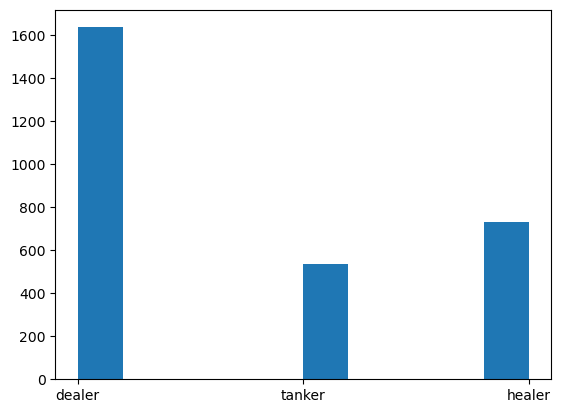

====================== LabelEncoding 이후의 분포입니다. ======================


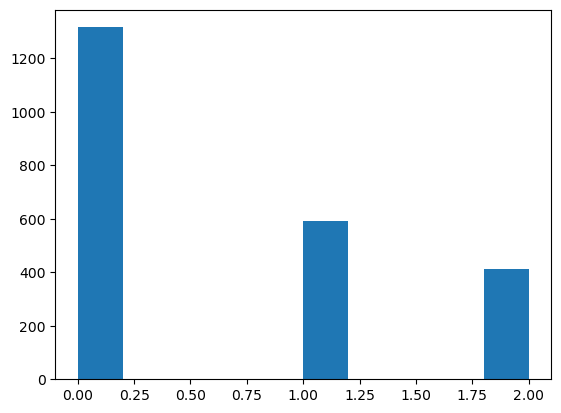

In [16]:
import matplotlib.pyplot as plt

# 1. LabelEncoding 이전의 분포 확인 (문자열 상태)
print("====================== LabelEncoding 이전의 분포입니다. ======================")
# 만약 y_train을 이미 변환했다면, 변환 전 원본 컬럼을 넣으세요.
plt.hist(tmp_df['mainjob']) 
plt.show()

# 2. LabelEncoding 이후의 분포 확인 (숫자 상태)
print("====================== LabelEncoding 이후의 분포입니다. ======================")
# 이전 단계에서 변환 완료한 y_train(또는 y_test)을 넣으세요.
plt.hist(y_train) 
plt.show()

In [17]:
import pandas as pd

# 1. 인코딩 전 원본의 dealer 개수 확인 (전체 vs Train)
print("--- [Before] 문자열 상태 개수 ---")
print(tmp_df['mainjob'].value_counts())

# 2. 인코딩 후 숫자의 개수 확인 (0이 dealer인지 확인)
print("\n--- [After] 인코딩(숫자) 상태 개수 ---")
# y_train이 numpy 배열이라면 pd.Series로 감싸서 확인
print(pd.Series(y_train).value_counts())

--- [Before] 문자열 상태 개수 ---
mainjob
dealer    1636
healer     729
tanker     534
Name: count, dtype: int64

--- [After] 인코딩(숫자) 상태 개수 ---
0    1316
1     592
2     411
Name: count, dtype: int64


<img src="./참고이미지/Q9/Q9_4.png" width="40%">

## Step3 모델 학습

<b>사용 인공지능 모델</b>
- 인공지능 모델은 ExplainableBoostingClassifier를 사용합니다.

<img src="./참고이미지/Q10/Q10_1.png" width="45%">

## **🔎 [주관식 과제 수행 시 유의사항]**

> **✅ 1. 정확한 출력값과 요구사항 이행 필수**  

주관식 채점은 다음 기준에 따라 평가됩니다.

1)출력 결과의 정확성  
- 제공된 예시 결과와 동일한 출력이 나와야 합니다.  
- 단, 실시간 데이터나 인공지능 학습 등으로 출력값에 변동성이 존재할 수 있는 문제는 예외로 처리합니다.  

2)문제 요구사항의 충실한 반영  
- 조건, 컬럼명, 출력 형식 등 모든 요구사항을 빠짐없이 반영해야 합니다.  
- 사소한 조건도 놓치지 않도록 세심하게 코드를 작성해 주세요.  


> **✅ 2. 완성된 코드 제출 필수**

가. 제출한 코드 셀은 채점 시 직접 실행하여 결과를 확인할 수 있습니다.  

- 재실행 시에도 동일한 결과가 나와야 정답으로 인정됩니다.  

나. 버전 차이에 따른 미세한 수치 차이는 감안하나, 결과 형태나 구조가 다르면 감점 또는 오답 처리될 수 있습니다.  

다. 시각화 문제에서 색상 지정이 없다면, 기본(default) 색상 사용을 전제로 합니다.  
- 환경에 따라 색상이 다르게 출력되더라도 불이익은 없습니다.  

> **✅ 3. 사용자 선언 함수/클래스 문제 주의사항**

사용자 정의 함수, 클래스, 메서드와 관련된 문제에서는 추가적인 코드 없이도 함수만으로 정답 결과가 도출되어야 합니다.  
- ❌ 함수 외부에서 plt.title, print, info() 등을 추가하여 결과를 보완하면 오답 처리됩니다.  

> **✅ 4. 함수/클래스 선언 시 일관된 결과 유지**

가. 함수, 클래스, 메서드는 반복 실행 시에도 항상 동일한 결과를 반환해야 합니다.  
나. 채점 중 재실행 결과가 다르면 오답으로 처리됩니다.  

> **📌 [안내 정리]**  

가. 문제의 모든 조건을 꼼꼼히 확인하고 반영해 주세요.  
나. 과제는 실무와 유사한 기준으로 평가되며, 요구 조건을 충족하지 않을 경우 0점 처리될 수 있습니다.  